In [4]:
import numpy as np
import matplotlib.pyplot as plt

from phase_shift import PhaseSolver, PhaseConfig

def correct(frame, mask):
    ys, xs = np.where(mask)
    corr = frame.astype(float).copy()
    for y, x in zip(ys, xs):
        nb  = frame[max(0,y-1):y+2, max(0,x-1):x+2]
        nbm = mask [max(0,y-1):y+2, max(0,x-1):x+2]
        good = nb[~nbm]
        if good.size: corr[y,x] = np.median(good)
    return corr

N = 30

In [6]:
# Read dark frames
data_dark = np.load("../../data/dark_400_20260913_171239.npz")
stack_dark = data_dark['stack'][0]

In [7]:
# Find and correct for hot pixels
frames = stack_dark           # (N,H,W), same gain+exposure as your data

m = frames.mean(0)                 # per-pixel mean  -> high dark current
s = frames.std(0)                  # per-pixel std   -> RTS/flicker

def rob(x, k=5):                   # robust threshold, unbiased by outliers
    med = np.median(x)
    mad = np.median(np.abs(x-med))*1.4826
    return np.abs(x-med) >= k*mad

mask = rob(m) | rob(s)             # (H,W) bool, True = hot
print(100*mask.mean(), "% hot")

stack_dark_corr = np.stack([correct(stack_dark[n], mask) for n in range(len(stack_dark))])
stack_dark_ref = stack_dark_corr.mean(axis=0)

0.10537166900420757 % hot


In [8]:
# Read ref bright frames
data_ref_bright = np.load("../../data/piezo_bright_400_20260913_171406.npz")
stack_ref_bright = data_ref_bright['stack'][0][:N]

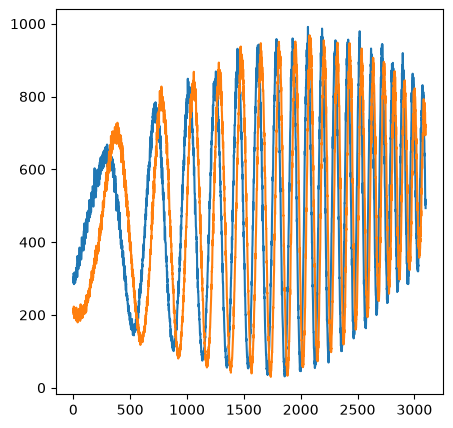

In [58]:
# Correct for hot pixels and subtract dark
stack_ref_bright_corr = np.stack([correct(stack_ref_bright[n], mask) for n in range(len(stack_ref_bright))])
stack_ref_bright_corr = np.maximum(stack_ref_bright_corr - stack_dark_ref, 0)

plt.figure(figsize=(5, 5))
plt.plot(stack_ref_bright_corr[0,1000])
plt.plot(stack_ref_bright_corr[20,1000])

In [10]:
# Compute noise
sigma_ref_n = np.sqrt(stack_ref_bright_corr*2.6596) / 2.6596    # (N,P), gain=100
sigma_ref_pixel = np.sqrt((sigma_ref_n**2).mean(0))          # (P,)

rms_ref_bright = np.sqrt((sigma_ref_pixel**2).mean())
noise_floor_ref_bright = np.sqrt((sigma_ref_pixel**2).mean()) / stack_ref_bright_corr.std()

print(f"RMS noise ref: {rms_ref_bright}")
print(f"Noise floor ref: {noise_floor_ref_bright}")

RMS noise ref: 13.165358703515661
Noise floor ref: 0.05594885092814367


In [57]:
iters = 30
tol = 1e-4
basis_kwargs = {"degree": 2}
rounds = 1

num = 10

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = True
cfg_d.gain_mode = "joint"
cfg_d.method_kwargs.update(iters=iters, tol=tol, basis_kwargs=basis_kwargs, rounds=rounds)

solver_d = PhaseSolver(cfg_d)
solver_d.fit(stack_ref_bright_corr[:num])
mp = solver_d.result.method_param
# print(f"num={num} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
#         f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
#         f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

In [55]:
r = solver_d.result
recon_err = r.reconstruction_error * np.sqrt(num / (num - 3))
print(recon_err)

13.518974215764851


In [7]:
num_range = np.arange(start=5, stop=31)
iters = 30
tol = 1e-4
refine_iters = 10
refine_tol = 1e-4

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = True
cfg_d.gain_mode = "joint"
cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=2,
                            refine_iters=refine_iters, refine_tol=refine_tol)

results_ref = {}
for num in num_range:
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_corr[:num])
    results_ref[num] = solver_d
    mp = solver_d.method_param_
    print(f"num={num} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
            f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
            f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

num=5 converged=True  reconstruction_error=8.4905  kappa_fit=3.21  refine_iters_run=6  rms_frac_history=['0.04136', '0.03639', '0.03536', '0.03506', '0.03493', '0.03487']
num=6 converged=True  reconstruction_error=9.5367  kappa_fit=3.19  refine_iters_run=6  rms_frac_history=['0.04410', '0.04053', '0.03967', '0.03939', '0.03928', '0.03923']
num=7 converged=True  reconstruction_error=10.2029  kappa_fit=3.17  refine_iters_run=5  rms_frac_history=['0.04461', '0.04266', '0.04214', '0.04199', '0.04194']
num=8 converged=True  reconstruction_error=10.6535  kappa_fit=3.17  refine_iters_run=5  rms_frac_history=['0.04639', '0.04441', '0.04397', '0.04385', '0.04380']
num=9 converged=True  reconstruction_error=11.0339  kappa_fit=3.18  refine_iters_run=5  rms_frac_history=['0.04760', '0.04601', '0.04554', '0.04540', '0.04535']
num=10 converged=True  reconstruction_error=11.3232  kappa_fit=3.17  refine_iters_run=4  rms_frac_history=['0.04831', '0.04694', '0.04661', '0.04653']
num=11 converged=True  r

In [113]:
num_range = np.arange(start=5, stop=31)
iters = 30
tol = 1e-4
refine_iters = 10
refine_tol = 1e-4

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = False
cfg_d.gain_mode = None#"joint"
cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=0,
                            refine_iters=refine_iters, refine_tol=refine_tol)

results_ref0_alpha_g = {}
for num in num_range:
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_ref_bright_corr[:num])
    results_ref0_alpha_g[num] = solver_d
    mp = solver_d.method_param_
    print(f"num={num} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
            f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
            f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

num=5 converged=False  reconstruction_error=12.3267  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=6 converged=False  reconstruction_error=14.6674  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=7 converged=False  reconstruction_error=16.2466  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=8 converged=False  reconstruction_error=16.2980  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=9 converged=False  reconstruction_error=16.0462  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=10 converged=False  reconstruction_error=16.4190  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=11 converged=False  reconstruction_error=17.2489  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=12 converged=False  reconstruction_error=17.6818  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=13 converged=False  reconstruction_error=17.5939  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
num=14 converged=False  

/var/folders/yh/m7ktw8tx7sb5h8fjhv5vf1bxt2hybb/T/ipykernel_73609/604017741.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Reconstruction error, RMS')

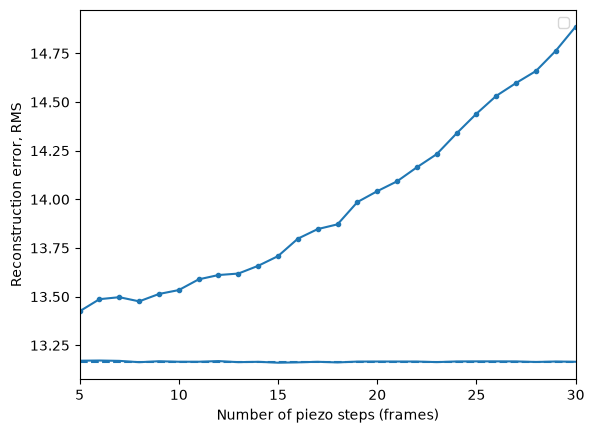

In [122]:
plt.plot(num_range, [results_ref[num].reconstruction_error_*np.sqrt(num/(num-3)) for num in num_range],'.-', color="tab:blue")
# plt.plot(num_range, [results_ref0[num].reconstruction_error_*np.sqrt(1-3/num) for num in num_range],'.-', color="tab:orange")
# plt.plot(num_range, [results_ref0_alpha[num].reconstruction_error_*np.sqrt(1-3/num) for num in num_range],'.-', color="tab:green")
# plt.plot(num_range, [results_ref0_alpha_g[num].reconstruction_error_*np.sqrt(1-3/num) for num in num_range],'.-', color="tab:red")
plt.plot(num_range, rms_ref_bright_arr)
plt.hlines(rms_ref_bright, 5, 30, color='tab:blue', linestyles='--')
#plt.text(6.5,8.7, "Noise floor")
plt.xlim([5, 30])
plt.legend()
plt.xlabel('Number of piezo steps (frames)')
plt.ylabel('Reconstruction error, RMS')

TypeError: float() argument must be a string or a real number, not 'StepFieldParam'

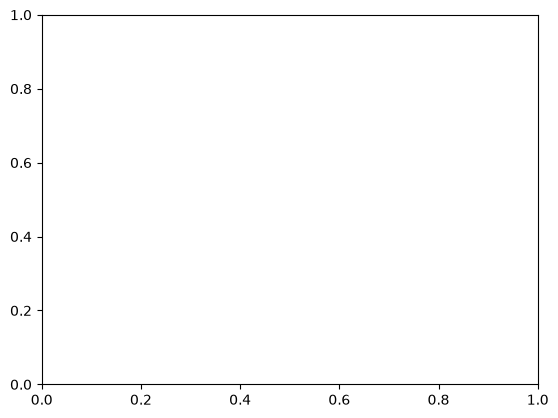

In [14]:
plt.plot(results_ref[30].method_param_, '.-')

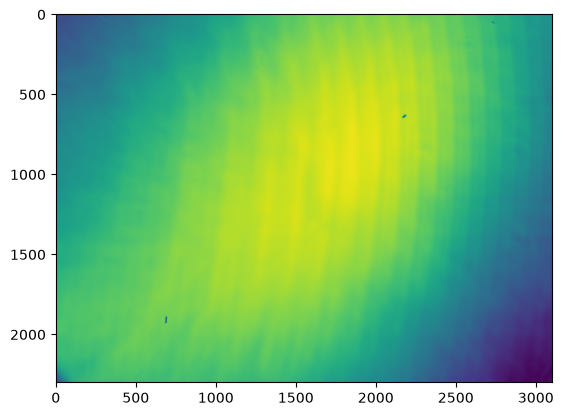

In [49]:
a = results_ref[20].a_
b = results_ref[20].b_
phi = results_ref[20].phi_
phi_error = results_ref[20].phi_error_
contrast = b/a

plt.imshow(contrast)

7.949256950020356


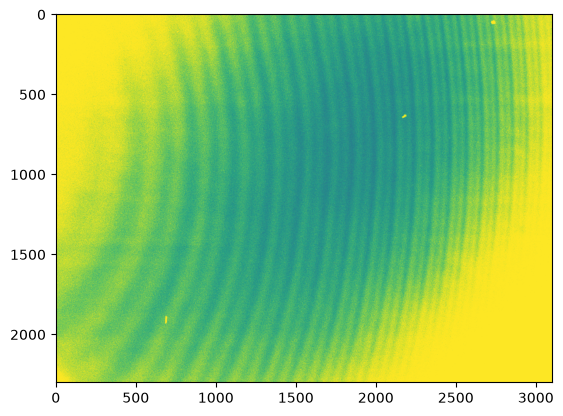

In [50]:
plt.imshow(phi_error*180/np.pi)
plt.clim([0, 1])

print(np.sqrt(np.mean(phi_error**2))*180/np.pi)

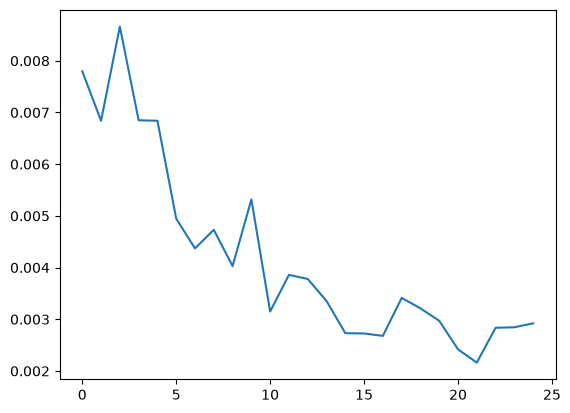

In [79]:
from phase.carrier import remove_carrier

phi_arr = np.asarray([remove_carrier(results_ref[i+5].phi_ * (results_ref[i+5].phi_.mean()/np.abs(results_ref[i+5].phi_.mean())),results_ref[i+5].b_).phi  for i in range(26)])
phi_diff = np.diff(phi_arr, axis=0)
phi_diff_error = np.mean(phi_diff**2, axis=(1,2))

plt.plot(phi_diff_error)
# plt.ylim([0, 0.1])

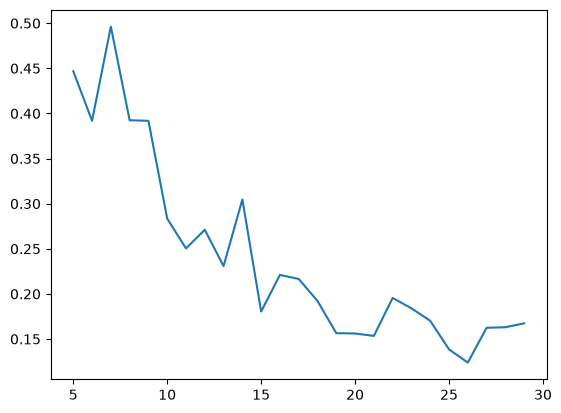

In [82]:
plt.plot(np.arange(5, 30), phi_diff_error*180/np.pi)

In [78]:
phi_arr[0].mean()/np.abs(phi_arr[0].mean())

np.float64(-1.0)

In [63]:
from phase.carrier import remove_carrier

res = remove_carrier(phi, b)

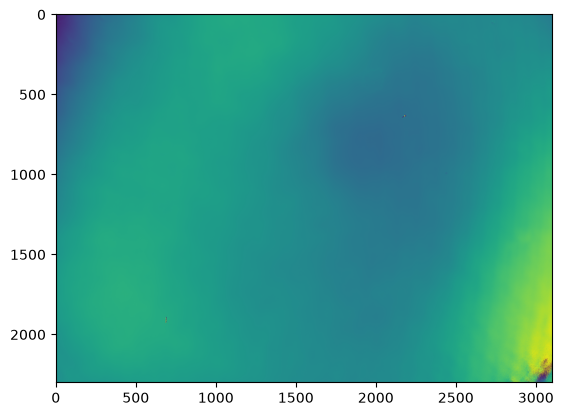

In [83]:
plt.imshow(res.phi)

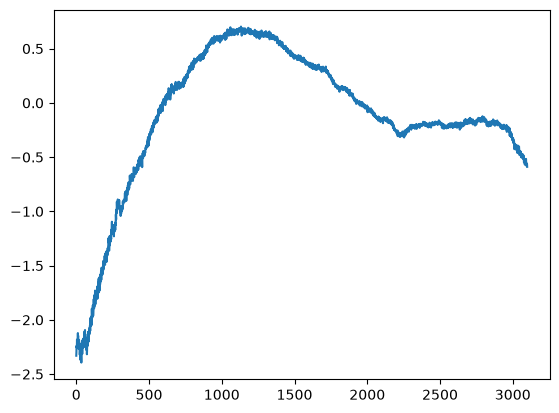

In [85]:
plt.plot(res.phi[0])